In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from magnetic_fields import simulate_field, compute_S, _stokes_and_polarization
import plotting_functions as pf
from scipy.stats import skew, skewnorm
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde
import pickle
import matplotlib.cm as cm
import seaborn as sns
from collections import defaultdict

In [2]:
# ── Configuration ──────────────────────────────────────────────────────────────

GEOMETRIES = {
    'uniform'  : {'iaxis': [2],    'label': 'Uniform'},
    'wavy'     : {'iaxis': [2],    'label': 'Wavy'},
    'helical'  : {'iaxis': [1, 2], 'label': 'Helical'},
    'hourglass': {'iaxis': [1, 2], 'label': 'Hourglass'},
}

# Map simulate_field geometry string -> what decision_tree should return
# Adjust these to match your exact decision_tree output strings
EXPECTED_OUTPUT = {
    ('uniform',   2): 'Uniform',
    ('wavy',      2): 'Wavy',
    ('helical',   1): 'Helical Axis = 1',
    ('helical',   2): 'Helical Axis = 2',
    ('hourglass', 1): 'Hourglass Axis = 1',
    ('hourglass', 2): 'Hourglass Axis = 2',
}


## Determine NH2 val for Geometry (from literature)

In [3]:
# NH2 ranges grounded in observations
# Sources: Crutcher (2012, ARA&A), Planck Collaboration (2015), 
#          Girart et al. (2006), Qiu et al. (2014)

GEOMETRY_NH2 = {
    'uniform'   : 1e20,   # diffuse ISM, ordered field (Planck 2015, Crutcher 2012)
    'wavy'      : 1e21,   # molecular cloud envelope (Crutcher 2012)
    'helical'   : 1e21,   # molecular cloud envelope (Crutcher 2012)
    'hourglass' : 1e22,   # dense/protostellar core (Girart+2006, Qiu+2014)
}

def get_nh2_for_geometry(geometry):
    key = geometry.lower().split()[0]
    if key not in GEOMETRY_NH2:
        raise ValueError(f"Unknown geometry '{geometry}'. "
                         f"Choose from {list(GEOMETRY_NH2.keys())}")
    return GEOMETRY_NH2[key]

## Add observational noise
- sP = 10%
- sPA = 1 degree
- BLOA = 10%
- NH2 = 10%

In [ ]:
def add_observational_noise(BLOS, NH2, blos_noise=0.1, nh2_noise=0.1, seed=None):

    rng = np.random.default_rng(seed)
    BLOS_noisy = BLOS * (1 + rng.normal(0, blos_noise)) # BLOS: fractional Gaussian noise on scalar
    NH2_noisy = NH2 * (1 + rng.normal(0, nh2_noise)) # NH2: fractional Gaussian noise on scalar

    return BLOS_noisy, NH2_noisy

### count peaks of PA distribution

In [ ]:
def count_peaks(samples, bandwidth=0.1, prominence=0.05):
    samples = np.asarray(samples).flatten()  # ensure 1D
    kde = gaussian_kde(samples, bw_method=bandwidth)
    x = np.linspace(-np.pi/2, np.pi/2, 1000)
    density = kde(x)
    density /= density.max()  # normalize
    peaks, props = find_peaks(density, prominence=prominence)
    return len(peaks), x[peaks], density

### use circular variance to better probe PA dispersion

In [6]:
def circular_variance(phi_map):
    """
    Circular variance of PA map. Range [0, 1].
    0 = perfectly ordered, 1 = fully random.
    """
    phi_flat = phi_map.flatten()
    R = np.abs(np.mean(np.exp(2j * phi_flat)))  # mean resultant length
    return 1 - R

### Decision tree with CV

In [40]:
def decision_tree_2(P, PHI, M_A, BLOS, NH2):

    Pflat = P.flatten()
    Pflat = Pflat[Pflat > 0]

    skew_val = skew(Pflat, bias=False)

    if skew_val > 0.2:
        CV = circular_variance(PHI)
        if CV > 0.3:
            med_P = np.median(Pflat)
            if med_P > 0.13:
                geometry = 'None'
                print('Super-Alfvenic, Geometry unrecoverable')
                print('Mach no: ', M_A, 'Skew: ', skew_val, 'CV: ', CV, 'P median: ', med_P)

            else:
                geometry = 'Hourglass Axis = 2'
                print('Sub-Alfvenic, geometry Hourglass Axis = 2')
        else:
            geometry = 'Helical Axis = 1'
            print('Sub-Alfvenic, geometry Helical Axis = 1')
            print('Mach no: ', M_A, 'Skew: ', skew_val, 'CV: ', CV)

    else:
        Pflat = P.flatten()
        Pflat = Pflat[Pflat > 0]

        a, loc, scale = skewnorm.fit(Pflat)
        x_fit = np.linspace(Pflat.min(), Pflat.max(), 300)
        P_peak = x_fit[np.argmax(skewnorm.pdf(x_fit, a, loc=loc, scale=scale))]

        # ── Step 2: Circular Variance ─────────────────────────
        CV = circular_variance(PHI)

        if P_peak <= 0.1:
            # low polarization fraction -> disordered or helical
            if CV > 0.5:
                geometry = 'Hourglass Axis = 2'
            else:
                geometry = 'Helical Axis = 1'

        elif 0.1 <= P_peak < 0.4:
            geometry = 'Helical Axis = 1'
            
        elif 0.4 <= P_peak <= 1:

            if CV < 0.1:
                # ordered field -> uniform or hourglass axis=1
                M_PHI = 7.6e-21 * NH2 / BLOS
                if M_PHI < 1:
                    geometry = 'Uniform'
                else:
                    geometry = 'Hourglass Axis = 1'

            elif 0.1 <= CV < 0.5:
                # moderate disorder -> hourglass axis=2
                geometry = 'Hourglass Axis = 2'

            elif 0.5 <= CV < 0.75:
                # wavy sits here based on observed CV ~ 0.57-0.71
                n_peaks, peak_loc, dens = count_peaks(samples=PHI, bandwidth=0.1, prominence=0.75)
                if n_peaks > 1:
                    geometry = 'Wavy'
                else:
                    geometry = 'Hourglass Axis = 2'

            else:
                # CV >= 0.75 -> fully disordered -> helical axis=2
                geometry = 'Helical Axis = 2'

        else:
            print('Peak P outside [0,1] range.')
            geometry = 'None'


    return geometry

### CV heatmaps

In [8]:
def plot_sstat_heatmaps(sstat_data, noise_vals, M_A_vals, geometries):
    
    geom_iaxis_pairs = [(geom, iaxis) 
                        for geom, cfg in geometries.items() 
                        for iaxis in cfg['iaxis']]
    
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))
    axes_flat = axes.flatten()

    for ax, (geom, iaxis) in zip(axes_flat, geom_iaxis_pairs):
        # build 2D grid: rows = noise, cols = M_A
        grid = np.zeros((len(noise_vals), len(M_A_vals)))

        for i, snoise in enumerate(noise_vals):
            for j, ima in enumerate(M_A_vals):
                vals = sstat_data.get((geom, iaxis, snoise, ima), [])
                grid[i, j] = np.mean(vals) if vals else np.nan

        im = ax.imshow(grid, aspect='auto', origin='lower',
                       cmap='viridis', vmin=0, vmax=1,
                       extent=[M_A_vals.min(), M_A_vals.max(),
                               -0.5, len(noise_vals) - 0.5])

        ax.set_yticks(range(len(noise_vals)))
        ax.set_yticklabels([str(s) for s in noise_vals], fontsize=9)
        ax.set_xlabel('$M_A$', fontsize=12)
        ax.set_ylabel('$\\sigma_{Q,U}$', fontsize=12)
        ax.set_title(f'{geom.capitalize()} (iaxis={iaxis})', fontsize=12)
        plt.colorbar(im, ax=ax, label='Circular Variance (CV)')

    plt.suptitle('Circular Variance vs $M_A$ and $\\sigma_{Q,U}$', fontsize=14)
    plt.tight_layout()
    plt.savefig('sstat_heatmaps.png', dpi=150)
    plt.show()

### Noise sweep

In [9]:
def run_noise_sweep(INPUT_GEOMETRY, M_A_VALS, SIGMA_VALS, N_TRIALS, TURB, GSIZE, ALPHA, IAXIS, BLOS_BASE, EXPECTED_LABEL):
    NH2     = get_nh2_for_geometry(INPUT_GEOMETRY)
    results = {s: np.zeros(len(M_A_VALS)) for s in SIGMA_VALS}
    for sigma in SIGMA_VALS:
        print("\nsigma_qu = {:.4f}".format(sigma))
        for i, ima in enumerate(M_A_VALS):
            correct = 0
            for _ in range(N_TRIALS):
                P, PHI, _ = simulate_field(geometry=INPUT_GEOMETRY, turbulence=TURB, M_A=ima,
                                           g_size=GSIZE, alpha=ALPHA, iaxis=IAXIS,
                                           anisotropy_strength=1.0, seed=None, snoise=sigma)
                BLOS_n, NH2_n = add_observational_noise(BLOS_BASE, NH2, blos_noise=0.1, nh2_noise=0.1)
                if decision_tree_2(P, PHI, ima, BLOS_n, NH2_n) == EXPECTED_LABEL:
                    correct += 1
            results[sigma][i] = correct / N_TRIALS
            print("  M_A={:.2f}  recovery={:.1%}".format(ima, results[sigma][i]), flush=True)
    return results

### recovery vs. MA plot

In [10]:
def plot_recovery_vs_MA(results, SIGMA_VALS, M_A_VALS, INPUT_GEOMETRY, IAXIS):
    fig, ax = plt.subplots(figsize=(9, 5))
    colors  = [cm.plasma(i / len(SIGMA_VALS)) for i in range(len(SIGMA_VALS))]
    for i, sigma in enumerate(SIGMA_VALS):
        ax.plot(M_A_VALS, results[sigma] * 100,
                color=colors[i], lw=2, marker='o', ms=4,
                label=r'$\sigma_{{q,u}}={:.3f}$'.format(sigma))
    ax.axhline(50, color='gray', lw=1, ls=':')
    ax.set_xlabel(r'$M_A$', fontsize=14)
    ax.set_ylabel('Recovery Fraction (%)', fontsize=14)
    ax.set_title('{}, iaxis={}'.format(INPUT_GEOMETRY, IAXIS), fontsize=13)
    ax.set_ylim(-5, 105)
    ax.legend(fontsize=10, loc='lower left')
    plt.tight_layout()
    plt.savefig('recovery_vs_MA_by_noise.png', dpi=150)
    plt.show()


### recovery heatmap

In [11]:
def plot_recovery_heatmap(results, SIGMA_VALS, M_A_VALS, INPUT_GEOMETRY, IAXIS, N_TRIALS):
    matrix = np.array([results[s] for s in SIGMA_VALS])
    fig, ax = plt.subplots(figsize=(8, 5))
    im      = ax.imshow(matrix * 100, aspect='auto', origin='upper', cmap='RdYlGn', vmin=0, vmax=100,
                        extent=[M_A_VALS.min(), M_A_VALS.max(), len(SIGMA_VALS) - 0.5, -0.5])
    plt.colorbar(im, ax=ax).set_label('Recovery Fraction (%)', fontsize=12)
    # for i in range(len(SIGMA_VALS)):
    #     for j in range(len(M_A_VALS)):
    #         ax.text(M_A_VALS[j], i, '{:.0f}%'.format(matrix[i, j] * 100),
    #                 ha='center', va='center', fontsize=5)
    ax.set_yticks(range(len(SIGMA_VALS)))
    ax.set_yticklabels([r'$\sigma_{{q,u}}={:.3f}$'.format(s) for s in SIGMA_VALS], fontsize=9)
    ax.set_xlabel(r'$M_A$', fontsize=13)
    ax.set_title('Recovery Heatmap — {}'.format(INPUT_GEOMETRY, IAXIS, N_TRIALS), fontsize=13)
    typical = [i for i, s in enumerate(SIGMA_VALS) if 0.005 <= s <= 0.02]
    if typical:
        ymin, ymax = min(typical) - 0.5, max(typical) + 0.5
        ax.axhspan(ymin, ymax, hatch='////', fill=False, edgecolor='steelblue', lw=1.5, label='Typical POL-2 range')
        ax.legend(fontsize=9, loc='lower right')
    plt.tight_layout()
    plt.savefig('recovery_heatmap.png', dpi=150)
    plt.show()

In [ ]:
def run_recovery_analysis(M_A_vals, n_trials, geometries, expected_output, TURB, GSIZE, ALPHA, BLOS):
    """
    For each geometry/axis combination, run n_trials noise realizations
    at each M_A value and record recovery fraction + confusion.

    Returns
    -------
    recovery  : dict keyed by (geometry, iaxis) -> array of shape (len(M_A_vals),)
    confusion : dict keyed by (true_label, predicted_label) -> int count
    """
    # recovery fraction per geometry/axis per M_A
    recovery  = {}
    # confusion counts: true -> predicted
    confusion = defaultdict(lambda: defaultdict(int))

    all_labels = list(expected_output.values())

    for geom, cfg in geometries.items():
        NH2 = get_nh2_for_geometry(geom)

        for iaxis in cfg['iaxis']:
            key        = (geom, iaxis)
            true_label = expected_output[key]
            rec_curve  = np.zeros(len(M_A_vals))

            print(f'\nRunning: {geom}, iaxis={iaxis}')

            for i, ima in enumerate(M_A_vals):
                correct = 0

                for trial in range(n_trials):
                    P, PHI, COS = simulate_field(geometry=geom, turbulence=TURB, M_A=ima, g_size=GSIZE, 
                                                 alpha=ALPHA, iaxis=iaxis, anisotropy_strength=1.0, seed=None, snoise=0.01)
                    
                    S_new = circular_variance(PHI)
                    print('Geometry: ', geom, 'M_A: ', ima, 'S-STAT: ',S_new)

                    predicted = decision_tree_2(P, PHI, ima, BLOS, NH2)

                    if predicted == true_label:
                        correct += 1

                    # accumulate confusion (use midpoint M_A for representative matrix)
                    if i == len(M_A_vals) // 2:
                        confusion[true_label][predicted] += 1
                
                print(f'  M_A={ima:.2f} -> recovery={correct/n_trials:.1%}', flush=True)
                
                rec_curve[i] = correct / n_trials

            recovery[key] = rec_curve
            print(f'  Mean recovery: {rec_curve.mean():.2f}')

    return recovery, confusion, all_labels

In [13]:
def plot_recovery_curves(recovery, M_A_vals, geometries, expected_output):

    colors = {
        'uniform'  : 'steelblue',
        'wavy'     : 'darkorange',
        'helical'  : 'forestgreen',
        'hourglass': 'crimson'}
    
    linestyles = {1: '--', 2: '-'}

    fig, ax = plt.subplots(figsize=(9, 5))

    for (geom, iaxis), rec_curve in recovery.items():
        label = f"{geometries[geom]['label']} (axis={iaxis})"
        ax.plot(M_A_vals, rec_curve * 100,
                color=colors[geom],
                ls=linestyles[iaxis],
                lw=2, marker='o', ms=4,
                label=label)

    ax.axhline(50, color='gray', lw=1, ls=':', label='50% chance')
    ax.axvline(1.0, color='k', lw=1, ls='--', alpha=0.4, label='$M_A = 1$')
    ax.set_xlabel('Alfvénic Mach Number $M_A$', fontsize=14)
    ax.set_ylabel('Recovery Fraction (%)', fontsize=14)
    ax.set_title('Decision Tree Recovery Fraction vs $M_A$', fontsize=15)
    ax.set_ylim(0, 105)
    ax.set_xlim(M_A_vals.min(), M_A_vals.max())
    ax.legend(fontsize=10, loc='lower left')
    ax.tick_params(labelsize=12)
    plt.tight_layout()
    plt.savefig('recovery_fraction.png', dpi=150)
    plt.show()


# ── Plot 2: Confusion matrix at mid M_A ───────────────────────────────────────
def plot_confusion_matrix(confusion, all_labels, M_A_vals):

    # build ordered label list (only those that appeared)
    labels = sorted(set(
        list(confusion.keys()) +
        [p for preds in confusion.values() for p in preds.keys()]))

    n = len(labels)
    matrix = np.zeros((n, n), dtype=int)

    for i, true in enumerate(labels):
        for j, pred in enumerate(labels):
            matrix[i, j] = confusion[true].get(pred, 0)

    # normalize by row (true class) to get fraction
    row_sums = matrix.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1   # avoid divide by zero
    matrix_norm = matrix / row_sums

    mid_MA = M_A_vals[len(M_A_vals) // 2]

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(matrix_norm, annot=True, fmt='.2f',
                xticklabels=labels, yticklabels=labels,
                cmap='Blues', vmin=0, vmax=1, ax=ax,
                linewidths=0.5, linecolor='gray')

    ax.set_xlabel('Predicted Geometry', fontsize=13)
    ax.set_ylabel('True Geometry', fontsize=13)
    ax.set_title(f'Confusion Matrix at $M_A \\approx {mid_MA:.2f}$', fontsize=14)
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150)
    plt.show()


In [14]:
def run_sstat_analysis(M_A_vals, n_trials, geometries, noise_vals,
                       turb, gsize, alpha, blos):
    """
    sstat_data : dict keyed by (geom, iaxis, snoise, ima) -> list of CV values
    """
    sstat_data = defaultdict(list)

    for geom, cfg in geometries.items():
        NH2 = get_nh2_for_geometry(geom)

        for iaxis in cfg['iaxis']:
            print(f'\nRunning: {geom}, iaxis={iaxis}')

            for snoise in noise_vals:
                for ima in M_A_vals:

                    for trial in range(n_trials):
                        P, PHI, COS = simulate_field(
                            geometry=geom, turbulence=turb, M_A=ima,
                            g_size=gsize, alpha=alpha, iaxis=iaxis,
                            anisotropy_strength=1.0, seed=None, snoise=snoise)

                        CV = circular_variance(PHI)
                        sstat_data[(geom, iaxis, snoise, ima)].append(CV)

                    mean_cv = np.mean(sstat_data[(geom, iaxis, snoise, ima)])
                    print(f'  geom={geom}, iaxis={iaxis}, snoise={snoise:.3f}, '
                          f'M_A={ima:.2f} -> CV={mean_cv:.4f}', flush=True)

    return sstat_data


# DECISION TREE

In [38]:
# def decision_tree(P, PHI, M_A, BLOS, NH2):    

#     if M_A <= 1:
#         # calculate P % distribution
#         Pflat    = P.flatten()
#         Pflat    = Pflat[Pflat > 0]
#         skew_val = skew(Pflat, bias=False)

#         a, loc, scale = skewnorm.fit(Pflat)
#         x_fit = np.linspace(Pflat.min(), Pflat.max(), 300)
        
#         # find peak of P % distribution
#         P_peak = x_fit[np.argmax(skewnorm.pdf(x_fit, a, loc=loc, scale=scale))]
#         peak_y = skewnorm.pdf(P_peak, a, loc=loc, scale=scale)

#         if 0 <= P_peak and P_peak <= 0.1:
#             S_MAP    = compute_S(PHI)
#             S_median = np.median(S_MAP)
#             # print('S Median:', S_median)
            
#             if S_median > 0.75:
#                 geometry = 'Hourglass Axis = 2'
#             else:
#                 geometry = 'Helical Axis = 1'

#         elif 0.1 <= P_peak and P_peak < 0.4:
#             geometry = 'Helical Axis = 1'

#         elif 0.4 <= P_peak and P_peak <= 1: 
#             # calculate dispersion in PA (S) parameter
#             S_MAP    = compute_S(PHI)
#             S_median = np.median(S_MAP)
#             # print('S Median:', S_median)

#             if 0.4 <= S_median and S_median <= 0.7:
#                 # calculate PA distribution shape
#                 # print('calculate PA distribution Shape')
#                 n_peaks, peak_loc, dens = count_peaks(samples=PHI, bandwidth=0.1, prominence=0.75)
#                 # print('peak info:', n_peaks)
#                 # if distribution shape has two+ peaks, then geometry is wavy
#                 if n_peaks > 1:
#                     geometry = 'Wavy'
#                 # if distribution shape is broad and has no peak, geometry is Helical Axis = 2
#                 else:
#                     geometry = 'Helical Axis = 2'
#             elif 0 <= S_median and S_median < 0.4:
#                 # Calculate mass-to-flux ratio (M/Φ)
#                 M_PHI = 7.6e-21 * NH2 / BLOS
#                 # print('Mass-to-Flux Ratio:', M_PHI)

#                 # if M/Φ < 1, geometry is uniform
#                 if M_PHI < 1:
#                     geometry = 'Uniform'

#                 # if M/Φ > 1, geometry is hourglass axis = 1
#                 elif M_PHI > 1:
#                     geometry = 'Hourglass Axis = 1'
#             else:
#                 print('S median = ', S_median, 'Too high to recover field, Field is fully perturbed.')
#                 geometry = 'None'
#         else:
#             print('Polarization fraction only exists between [0,1], peak P found is outside this range.')
#             geometry = 'None'
#     else:
#         print("Turbulence is Super-Alfvenic, Geometry not recoverable :(")
#         geometry = 'None'
#     return geometry

### Run decision tree to test

In [29]:
# input params
M_A = np.linspace(0.05, 1, 5)
gsize = 256
alpha = 0
BLOS = 5 #um
input_geometry = 'uniform'
turb = 'gs95'
iaxis = 2
NH2 = get_nh2_for_geometry(input_geometry)

output_geos = []

for ima in M_A:
    P, PHI, COS = simulate_field(geometry=input_geometry, turbulence=turb, M_A=ima, g_size=gsize,
                                 alpha=alpha, iaxis=iaxis, anisotropy_strength=1.0, seed=None, snoise=0.005)

    BLOS, NH2 = add_observational_noise(BLOS, NH2, blos_noise=0.1, nh2_noise=0.1)

    output_geo = decision_tree_2(P, PHI, ima, BLOS, NH2)
    print('Geometry Found: ', output_geo, 'M_A = ', ima)
    output_geos.append(output_geo)

Geometry Found:  Uniform M_A =  0.05
Geometry Found:  Uniform M_A =  0.2875
Geometry Found:  Uniform M_A =  0.525
Geometry Found:  Uniform M_A =  0.7625
Geometry Found:  Hourglass Axis = 2 M_A =  1.0


## Visualize Recovery for increasing Normalized Stokes RMS noise

In [ ]:
INPUT_GEOMETRY = 'uniform'
IAXIS          = 2
TURB           = 'gs95'
GSIZE          = 256
ALPHA          = 0
BLOS_BASE      = 5.0
N_TRIALS       = 1
M_A_VALS       = np.linspace(0.05, 1.0, 10)
SIGMA_VALS     = [0.0, 0.005, 0.01, 0.02, 0.05, 0.10]
EXPECTED_LABEL = 'Uniform'

results = run_noise_sweep(INPUT_GEOMETRY, M_A_VALS, SIGMA_VALS, N_TRIALS, TURB, GSIZE, ALPHA, IAXIS, BLOS_BASE, EXPECTED_LABEL)


sigma_qu = 0.0000
  M_A=0.05  recovery=100.0%
  M_A=0.16  recovery=100.0%
  M_A=0.26  recovery=100.0%
Sub-Alfvenic, geometry Helical Axis = 1
Mach no:  0.36666666666666664 Skew:  0.3169153762850947 CV:  0.00013236895228152523
  M_A=0.37  recovery=0.0%
  M_A=0.47  recovery=100.0%
  M_A=0.58  recovery=100.0%
Sub-Alfvenic, geometry Helical Axis = 1
Mach no:  0.6833333333333333 Skew:  0.2694000844464647 CV:  0.0008957665352988808
  M_A=0.68  recovery=0.0%
  M_A=0.79  recovery=100.0%
  M_A=0.89  recovery=100.0%
  M_A=1.00  recovery=0.0%

sigma_qu = 0.0100
  M_A=0.05  recovery=100.0%
  M_A=0.16  recovery=100.0%
  M_A=0.26  recovery=100.0%
  M_A=0.37  recovery=100.0%
  M_A=0.47  recovery=100.0%
  M_A=0.58  recovery=100.0%
  M_A=0.68  recovery=100.0%
  M_A=0.79  recovery=100.0%
  M_A=0.89  recovery=100.0%
  M_A=1.00  recovery=0.0%

sigma_qu = 0.0500
  M_A=0.05  recovery=100.0%
  M_A=0.16  recovery=100.0%
  M_A=0.26  recovery=100.0%
  M_A=0.37  recovery=100.0%
  M_A=0.47  recovery=100.0%
  M_A

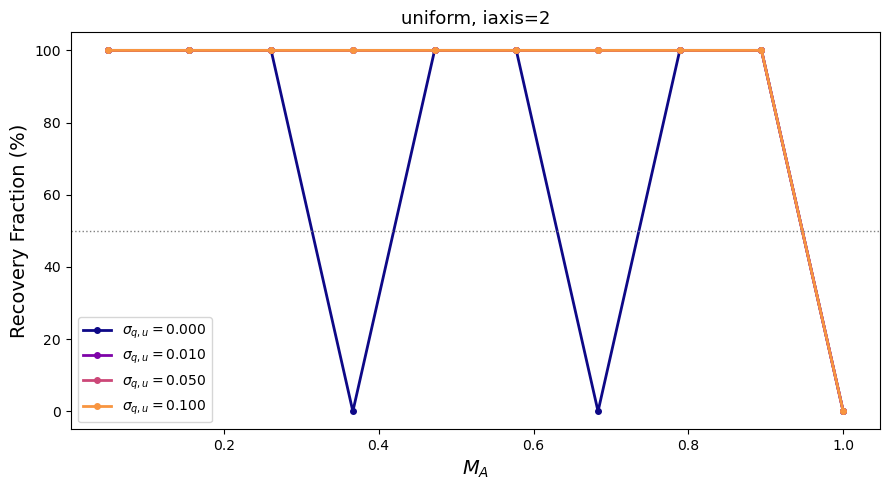

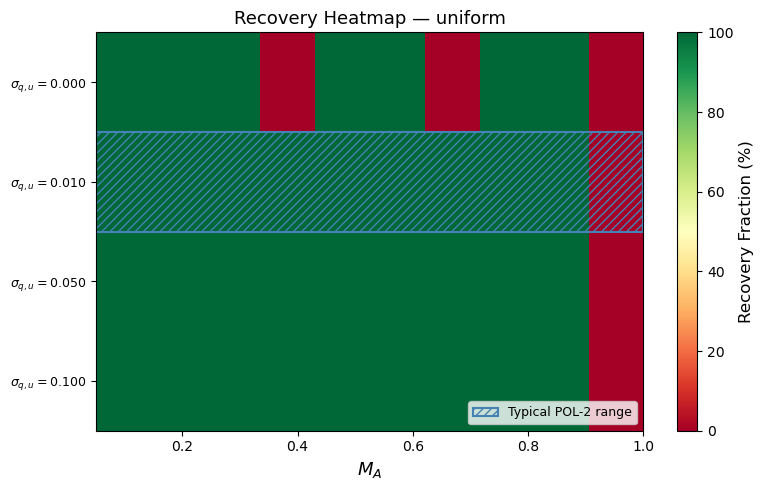

In [52]:
plot_recovery_vs_MA(results, SIGMA_VALS, M_A_VALS, INPUT_GEOMETRY, IAXIS)
plot_recovery_heatmap(results, SIGMA_VALS, M_A_VALS, INPUT_GEOMETRY, IAXIS, N_TRIALS)

## Visualize the Recovery Fraction 

In [ ]:
M_A_VALS  = np.linspace(0.05, 1.0, 5)
N_TRIALS  = 1       # number of noise realizations per M_A point
GSIZE     = 256
ALPHA     = 0
BLOS      = 5.0      # uG
TURB      = 'gs95'

# ── Run statistical analysis ───────────────────────────────────────────────────


recovery, confusion, all_labels = run_recovery_analysis(M_A_VALS, N_TRIALS, GEOMETRIES, EXPECTED_OUTPUT)





Running: uniform, iaxis=2
Geometry:  uniform M_A:  0.05 S-STAT:  1.5743430011982973e-05
  M_A=0.05 -> recovery=100.0%
Geometry:  uniform M_A:  0.2875 S-STAT:  9.707452233442826e-05
  M_A=0.29 -> recovery=100.0%
Geometry:  uniform M_A:  0.525 S-STAT:  0.0007208014849775513
  M_A=0.53 -> recovery=100.0%
Geometry:  uniform M_A:  0.7625 S-STAT:  0.0024019738841964955
  M_A=0.76 -> recovery=100.0%
Geometry:  uniform M_A:  1.0 S-STAT:  0.1437436507974419
  M_A=1.00 -> recovery=0.0%
  Mean recovery: 0.80

Running: wavy, iaxis=2
Geometry:  wavy M_A:  0.05 S-STAT:  0.7069547150624091
  M_A=0.05 -> recovery=100.0%
Geometry:  wavy M_A:  0.2875 S-STAT:  0.7031266356903989
  M_A=0.29 -> recovery=100.0%
Geometry:  wavy M_A:  0.525 S-STAT:  0.7102850229832574
  M_A=0.53 -> recovery=100.0%
Geometry:  wavy M_A:  0.7625 S-STAT:  0.7159786087246063
  M_A=0.76 -> recovery=100.0%
Geometry:  wavy M_A:  1.0 S-STAT:  0.7678466287380397
  M_A=1.00 -> recovery=0.0%
  Mean recovery: 0.80

Running: helical, iaxi

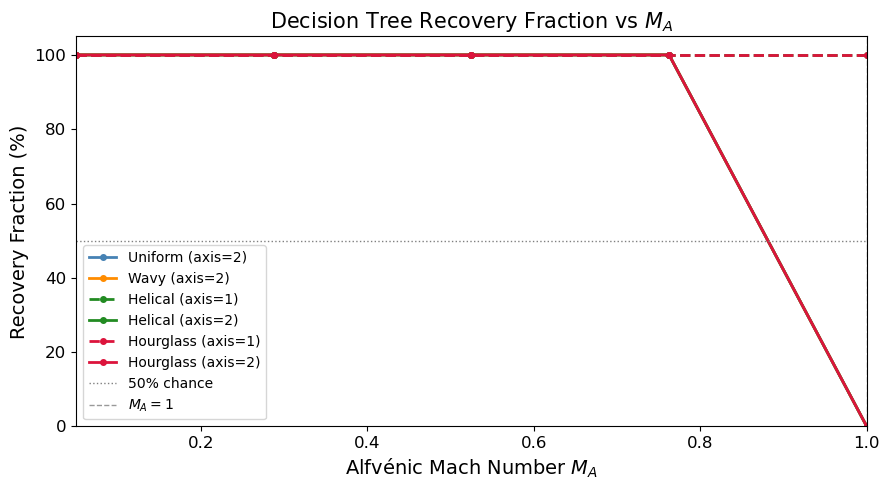

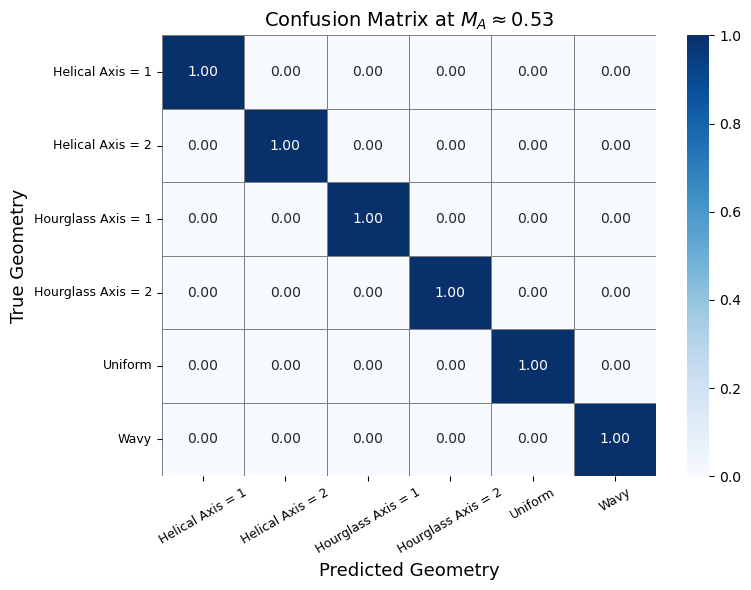

In [ ]:
# ── Plot 1: Recovery fraction vs M_A ──────────────────────────────────────────



plot_recovery_curves(recovery, M_A_VALS, GEOMETRIES, EXPECTED_OUTPUT)
plot_confusion_matrix(confusion, all_labels, M_A_VALS)

## Run S analysis

In [ ]:
# NOISE_VALS = [0.0, 0.005, 0.01, 0.02, 0.05, 0.10]
# M_A_VALS  = np.linspace(0.05, 1.0, 5)
# N_TRIALS  = 1       # number of noise realizations per M_A point
# GSIZE     = 256
# ALPHA     = 0
# BLOS      = 5.0      # uG
# TURB      = 'gs95'


# # ── Run ────────────────────────────────────────────────────────────────────────
# sstat_data = run_sstat_analysis(
#     M_A_vals  = np.linspace(0.05, 1.0, 10),
#     n_trials  = 1,
#     geometries= GEOMETRIES,
#     noise_vals= NOISE_VALS,
#     turb      = TURB,
#     gsize     = GSIZE,
#     alpha     = ALPHA,
#     blos      = BLOS,
# )



In [9]:
# def plot_sstat_histograms(sstat_data, noise_vals, geometries):
#     geom_iaxis_pairs = [(geom, iaxis) 
#                         for geom, cfg in geometries.items() 
#                         for iaxis in cfg['iaxis']]
    
#     fig, axes = plt.subplots(3, 2, figsize=(8, 8), sharey=False)
#     axes_flat = axes.flatten()

#     colors = plt.cm.plasma(np.linspace(0, 0.9, len(noise_vals)))

#     for ax, (geom, iaxis) in zip(axes_flat, geom_iaxis_pairs):
#         for color, snoise in zip(colors, noise_vals):
#             cv_all = []
#             for key, vals in sstat_data.items():
#                 g, ia, sn, ima = key
#                 if g == geom and ia == iaxis and sn == snoise:
#                     cv_all.extend(vals)

#             ax.hist(cv_all, bins=30, alpha=0.5, color=color,
#                     label=f'$\\sigma_{{Q,U}}$={snoise}', density=True)

#         ax.set_title(f'{geom.capitalize()} (iaxis={iaxis})', fontsize=12)
#         ax.set_ylabel('Density', fontsize=11)
#         ax.legend(fontsize=7, loc='upper left')

#     axes[2][1].set_xlabel('Circular Variance (CV)', fontsize=11)
#     axes[2][0].set_xlabel('Circular Variance (CV)', fontsize=11)

#     plt.tight_layout()
#     plt.savefig('sstat_histograms.png', dpi=150)
#     plt.show()

# plot_sstat_histograms(sstat_data, NOISE_VALS, GEOMETRIES)


Running: uniform, iaxis=2
  geom=uniform, iaxis=2, snoise=0.000, M_A=0.05 -> CV=0.0000
  geom=uniform, iaxis=2, snoise=0.000, M_A=0.21 -> CV=0.0001
  geom=uniform, iaxis=2, snoise=0.000, M_A=0.36 -> CV=0.0003
  geom=uniform, iaxis=2, snoise=0.000, M_A=0.52 -> CV=0.0004
  geom=uniform, iaxis=2, snoise=0.000, M_A=0.67 -> CV=0.0008
  geom=uniform, iaxis=2, snoise=0.000, M_A=0.83 -> CV=0.0018
  geom=uniform, iaxis=2, snoise=0.000, M_A=0.98 -> CV=0.0040
  geom=uniform, iaxis=2, snoise=0.000, M_A=1.14 -> CV=0.5567
  geom=uniform, iaxis=2, snoise=0.000, M_A=1.29 -> CV=0.5858
  geom=uniform, iaxis=2, snoise=0.000, M_A=1.45 -> CV=0.5078
  geom=uniform, iaxis=2, snoise=0.000, M_A=1.60 -> CV=0.6476
  geom=uniform, iaxis=2, snoise=0.000, M_A=1.76 -> CV=0.2989
  geom=uniform, iaxis=2, snoise=0.000, M_A=1.91 -> CV=0.8330
  geom=uniform, iaxis=2, snoise=0.000, M_A=2.07 -> CV=0.7076
  geom=uniform, iaxis=2, snoise=0.000, M_A=2.22 -> CV=0.5152
  geom=uniform, iaxis=2, snoise=0.000, M_A=2.38 -> CV=0.45

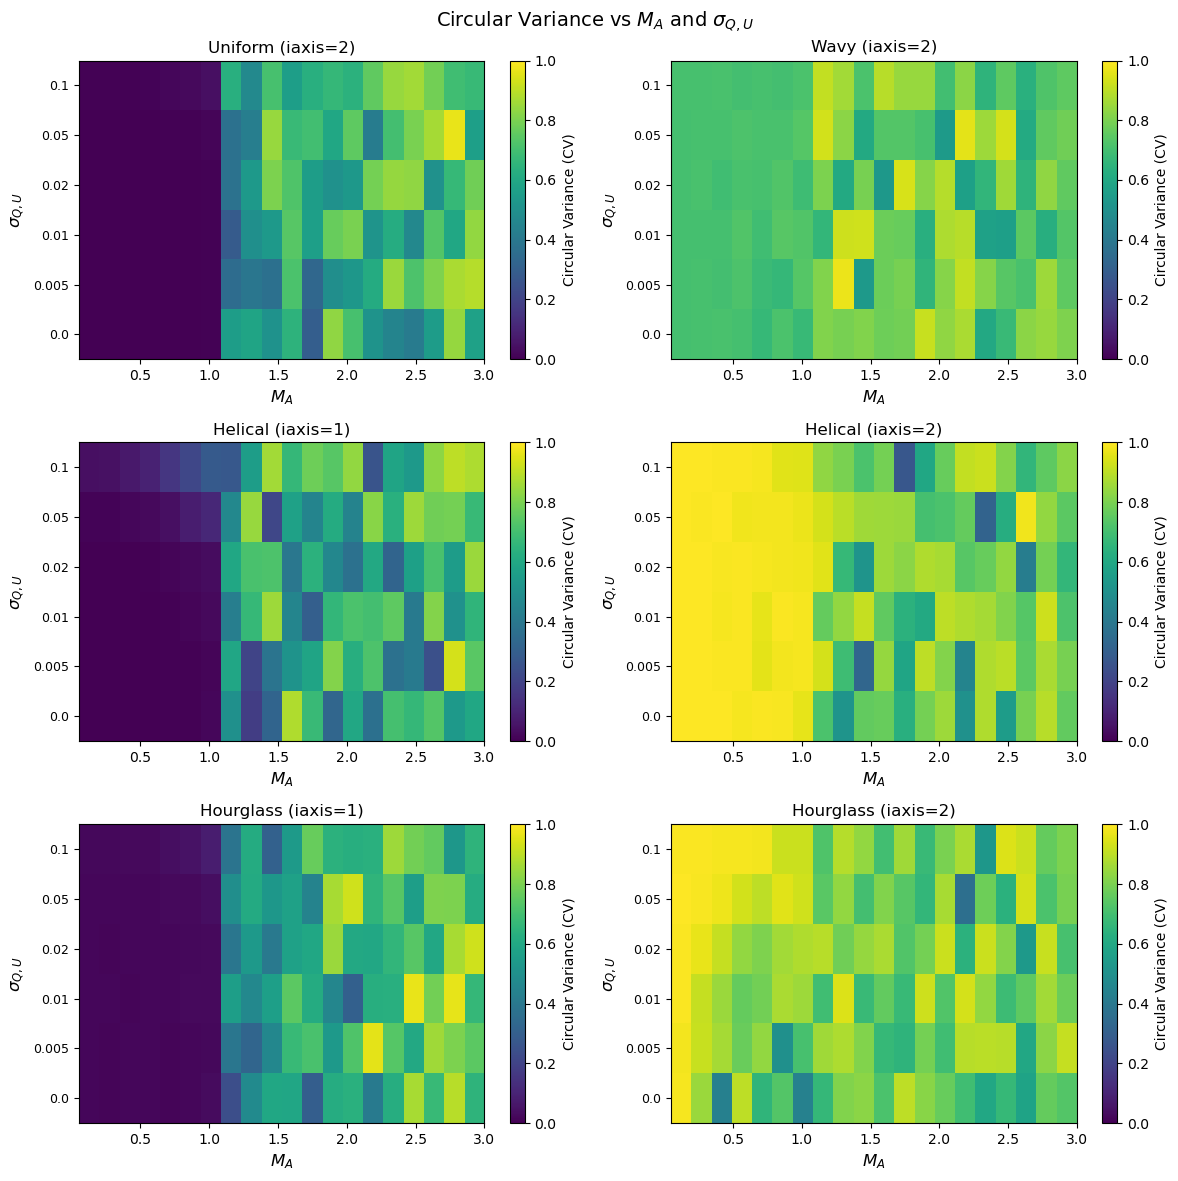

In [39]:
NOISE_VALS = [0.0, 0.005, 0.01, 0.02, 0.05, 0.10]
M_A_VALS  = np.linspace(0.05, 3.0, 20)
N_TRIALS  = 1       # number of noise realizations per M_A point
GSIZE     = 256
ALPHA     = 0
BLOS      = 5.0      # uG
TURB      = 'gs95'

sstat_data = run_sstat_analysis(M_A_vals=M_A_VALS, n_trials=1, geometries=GEOMETRIES, noise_vals=NOISE_VALS, turb =TURB, gsize=GSIZE, alpha=ALPHA, blos=BLOS)

plot_sstat_heatmaps(sstat_data, NOISE_VALS, M_A_VALS, GEOMETRIES)

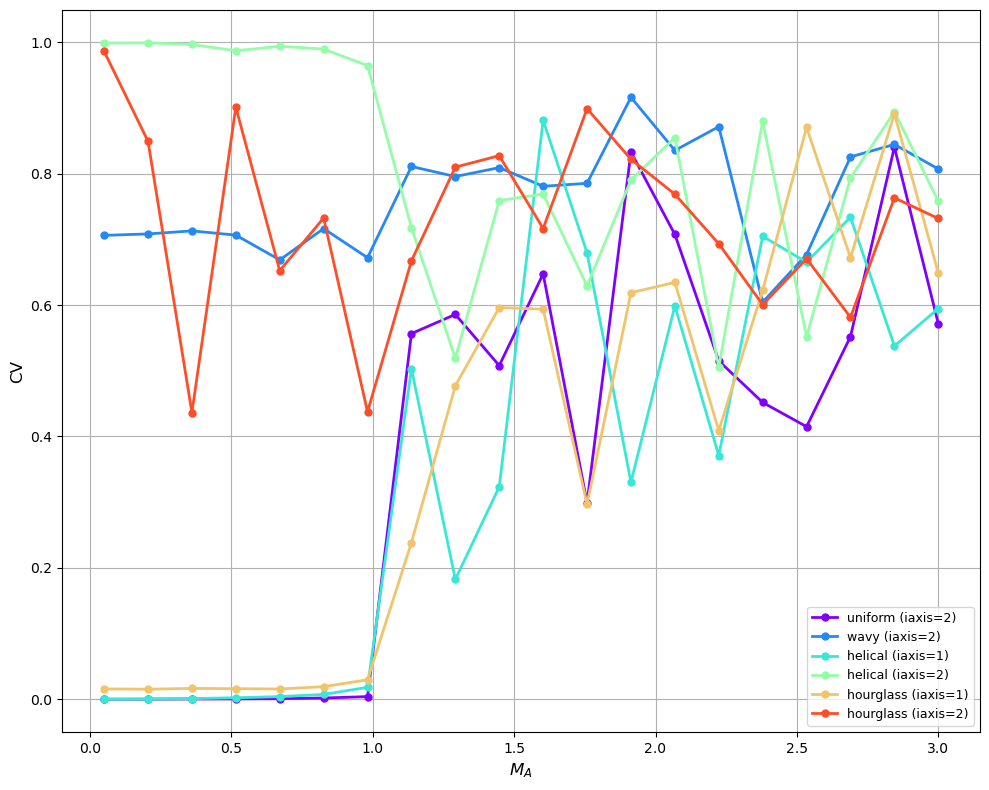

In [48]:
def plot_CV_MA(sstat_data, noise_vals, M_A_vals, geometries):
    
    geom_iaxis_pairs = [(geom, iaxis) 
                        for geom, cfg in geometries.items() 
                        for iaxis in cfg['iaxis']]
    
    colors = plt.cm.rainbow(np.linspace(0, 0.9, len(geom_iaxis_pairs)))
    
    plt.figure(figsize=(10, 8))

    for icolor, (geom, iaxis) in zip(colors, geom_iaxis_pairs):
        # only plot snoise=0 for clarity, or pick one noise level
        snoise = noise_vals[0]
        
        cv_means = []
        for ima in M_A_vals:
            vals = sstat_data.get((geom, iaxis, snoise, ima), [])
            cv_means.append(np.mean(vals) if vals else np.nan)

        plt.plot(M_A_vals, cv_means, marker='o', color=icolor, 
                 linestyle='-', lw=2, ms=5,
                 label=f'{geom} (iaxis={iaxis})')

    plt.xlabel('$M_A$', fontsize=12)
    plt.ylabel('CV', fontsize=12)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.grid()
    plt.show()
plot_CV_MA(sstat_data, NOISE_VALS, M_A_VALS, GEOMETRIES)

In [ ]:
# def mass_to_flux_ratio(B_LOS, N_H2):
#     """
#     Normalized mass-to-flux ratio for sub-Alfvénic regime (M_A < 1).
#     In ordered field conditions, B_LOS is used directly as a lower
#     bound on B_tot, which is tighter than the random-field sqrt(3) 
#     correction (Crutcher 2004).

#     Parameters
#     ----------
#     B_LOS_uG : LOS B field from Zeeman [micro-Gauss]
#     N_H2_cm2 : column density [cm^-2]

#     Returns
#     -------
#     lambda : normalized mass-to-flux ratio (lambda > 1: supercritical,
#                                              lambda < 1: subcritical)
